# S&P 500 Equity+Options: Strategy Assessment

This notebook closes the corrected v3.1 validation pipeline without reopening
the 2021 holdout. It traces one primary-label carrier from the equal-weight
baseline through allocation, costs, and fixed risk controls, then separates
that result from the historical IPCA holdout observation already stored in
the registry.

**Learning objectives**

1. Reconstruct the current carrier from configured, full-coverage registry
   rows rather than from the global maximum Sharpe.
2. Read stage progression, cost survival, paired risk uncertainty, and
   selection adjustment as distinct diagnostics.
3. Enforce one holdout use when methodology repairs change the validation
   carrier after the holdout has already been observed.
4. Produce a publication assessment that distinguishes validation evidence
   from unresolved out-of-sample efficacy.

**Book reference:** Chapter 20, Sections 20.1, 20.6, and 20.7.

**Prerequisites:** notebooks `14_backtest` through `17_risk_management` and
their corrected v3.1 registry rows. This notebook is read-only: it trains no
model, runs no backtest, and writes no registry result.

**Population scope:** The case study uses a current-constituent roster rather
than point-in-time S&P 500 membership. Historical results describe this
retrospective roster and do not establish performance for the index's
membership process or a prospective S&P 500 population.

In [1]:
"""S&P 500 Equity+Options: corrected strategy assessment."""

import json
import sqlite3
import warnings

import matplotlib.pyplot as plt
import polars as pl

warnings.filterwarnings("ignore")

Shared helpers reconstruct the configured funnel and its uncertainty from
registry artifacts without launching another training or evaluation run.

In [2]:
from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.backtest_loaders import get_backtest_config
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    set_backtest_costs_bps,
    set_backtest_costs_per_share,
    strategy_view,
)
from case_studies.utils.cv_window import canonical_window
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_backtest_fold_metrics,
    read_predictions,
    resolve_best_backtest_runs,
    resolve_best_predictions,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_cost_grid_bps,
    get_cost_grid_half_spread_usd,
    get_per_share_commission,
    get_position_risk_controls,
    get_top_n_predictions,
)
from case_studies.utils.uncertainty import (
    compute_cohort_metrics,
    compute_paired_uncertainty,
    load_daily_returns_with_timestamp,
    periods_per_year_from_setup,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title

In [3]:
CASE_STUDY = "sp500_equity_option_analytics"
SEED = 42

In [4]:
CASE_DIR = get_case_study_dir(CASE_STUDY)
REGISTRY_DB = CASE_DIR / "run_log" / "registry.db"
bt_config = get_backtest_config(CASE_STUDY)
LABEL = bt_config.primary_label
PERIODS_PER_YEAR = periods_per_year_from_setup(CASE_STUDY)
CONFIGURED_COST_BPS = bt_config.commission_bps + bt_config.slippage_bps
explorer = BacktestExplorer(CASE_STUDY)
set_global_seeds(SEED)

print(f"Case study: {CASE_STUDY}; corrected label: {LABEL}; mode: registry read-only")

Case study: sp500_equity_option_analytics; corrected label: fwd_ret_5d; mode: registry read-only


## 1. Reconstruct the corrected carrier

The funnel advances ten distinct full-coverage baseline configurations on the
primary label, filters allocation rows to the active five-method grid, and
filters risk rows to the 14 predeclared controls. Historical conformal rows,
alternate labels, and full-validation MAE-calibrated rules cannot enter.

In [5]:
top_predictions = resolve_best_predictions(
    CASE_STUDY,
    LABEL,
    split="validation",
    stage="signal",
    top_n=get_top_n_predictions(CASE_STUDY, "allocation"),
    checkpoints_per_config=get_checkpoints_per_config(CASE_STUDY),
)
selected_prediction_hashes = top_predictions["prediction_hash"].to_list()
active_allocators = {item["method"] for item in get_allocators(CASE_STUDY)}
baseline_pool = resolve_best_backtest_runs(
    CASE_STUDY,
    LABEL,
    split="validation",
    stage="signal",
    top_n=9999,
).filter(pl.col("prediction_hash").is_in(selected_prediction_hashes))
allocation_pool = resolve_best_backtest_runs(
    CASE_STUDY,
    LABEL,
    split="validation",
    stage="allocation",
    top_n=9999,
).filter(pl.col("prediction_hash").is_in(selected_prediction_hashes))
candidate_pool = pl.concat([baseline_pool, allocation_pool], how="diagonal_relaxed").unique(
    "backtest_hash"
)

Cost and risk advance the top validation strategy from the union of the
equal-weight baseline and active alternative allocators.

In [6]:
eligible_strategies = []
for row in candidate_pool.iter_rows(named=True):
    strategy = strategy_view(json.loads(row["spec_json"]))
    allocator = strategy.get("allocation", {}).get("method", "equal_weight")
    if allocator == "equal_weight" or allocator in active_allocators:
        eligible_strategies.append(
            {
                **row,
                "allocator": allocator,
                "top_k": strategy.get("signal", {}).get("top_k"),
            }
        )
if not eligible_strategies:
    raise RuntimeError("No eligible corrected baseline or allocation rows found")
strategy_carrier = (
    pl.DataFrame(eligible_strategies).sort("sharpe", descending=True).row(0, named=True)
)

The canonical fold boundary incorporates the five-session outcome horizon.
The selected prediction artifact must not extend beyond that sealed date.

In [7]:
validation_window = canonical_window(CASE_STUDY, LABEL, split="validation")
carrier_predictions = read_predictions(CASE_STUDY, strategy_carrier["prediction_hash"])
latest_decision = carrier_predictions["timestamp"].max()
latest_decision_date = (
    latest_decision.date() if hasattr(latest_decision, "date") else latest_decision
)
if validation_window is None or latest_decision_date > validation_window[1]:
    raise RuntimeError("The strategy carrier crosses the sealed validation-outcome boundary")
carrier_returns = load_daily_returns_with_timestamp(
    CASE_STUDY,
    strategy_carrier["backtest_hash"],
)
if carrier_returns is None:
    raise RuntimeError("The strategy carrier has no registered daily-return artifact")
registered_window = (
    carrier_returns["timestamp"].min(),
    carrier_returns["timestamp"].max(),
)
if registered_window != validation_window:
    raise RuntimeError(
        "The registered strategy carrier does not cover the canonical validation window: "
        f"registered={registered_window}, canonical={validation_window}"
    )
print(
    f"Sealed validation window: {validation_window[0]} to {validation_window[1]}; "
    f"carrier latest decision: {latest_decision_date}"
)

Sealed validation window: 2019-01-07 to 2020-12-23; carrier latest decision: 2020-12-23


In [8]:
fixed_controls = get_position_risk_controls(CASE_STUDY)
risk_plans = []
base_spec = json.loads(strategy_carrier["spec_json"])
execution = base_spec["backtest_config"]["execution"]
metadata = base_spec["backtest_config"]["metadata"]
stops = base_spec["backtest_config"]["stops"]
if (
    execution["execution_mode"] != "next_bar"
    or execution["execution_price"] != "open"
    or metadata["cadence"] != "weekly_friday_close"
    or metadata["fill_timing"] != "MONDAY_OPEN"
    or stops["trail_stop_timing"] != "lagged"
):
    raise RuntimeError("Carrier execution or stop timing permits same-bar information use")
for control in fixed_controls:
    spec = clone_backtest_spec(base_spec)
    spec["chapter"] = "ch19"
    rule = {"type": control["type"]}
    if control["type"] == "time_exit":
        rule["bars"] = control["bars"]
    else:
        rule["threshold"] = control["threshold"]
    spec["strategy"]["risk"] = {
        "name": control["name"],
        "position_rules": [rule],
    }
    risk_plans.append(
        {
            "risk_name": control["name"],
            "risk_type": control["type"],
            "backtest_hash": backtest_hash_from_parts(strategy_carrier["prediction_hash"], spec),
        }
    )

Exact planned hashes prevent retired or tuned-on-validation rules from
entering the fixed risk-control surface.

In [9]:
risk_hashes = [plan["backtest_hash"] for plan in risk_plans]
with sqlite3.connect(REGISTRY_DB) as db:
    risk_metrics = pl.read_database(
        f"""
        SELECT b.backtest_hash, b.prediction_hash, b.stage,
               bm.sharpe, bm.sharpe_ci95_lo, bm.sharpe_ci95_hi,
               bm.max_drawdown, bm.cagr, bm.total_return
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        WHERE b.backtest_hash IN ({",".join("?" for _ in risk_hashes)})
        """,
        connection=db,
        execute_options={"parameters": risk_hashes},
    )
risk_surface = pl.DataFrame(risk_plans).join(risk_metrics, on="backtest_hash", how="inner")
if len(risk_surface) != len(risk_plans):
    raise RuntimeError(f"Expected {len(risk_plans)} fixed risk rows, found {len(risk_surface)}")
if risk_surface.filter(pl.col("stage") != "risk_overlay").height:
    raise RuntimeError("A corrected risk hash has the wrong registry stage")
no_overlay = {
    "risk_name": "No overlay",
    "risk_type": "none",
    "backtest_hash": strategy_carrier["backtest_hash"],
    "prediction_hash": strategy_carrier["prediction_hash"],
    "sharpe": strategy_carrier["sharpe"],
}
risk_candidates = pl.concat([risk_surface, pl.DataFrame([no_overlay])], how="diagonal_relaxed")
risk_winner = risk_candidates.sort("sharpe", descending=True).row(0, named=True)

In [10]:
baseline_row = (
    explorer.best(
        stage="signal",
        top_n=9999,
        label=LABEL,
        prediction_hashes=[strategy_carrier["prediction_hash"]],
    )
    .sort("sharpe", descending=True)
    .row(0, named=True)
)

The visible carrier path retains the equal-weight starting point, the best
pre-risk strategy, and the risk decision only when it improves validation.

In [11]:
carrier_rows = [
    {
        "stage": "Equal weight",
        "backtest_hash": baseline_row["backtest_hash"],
        "sharpe": baseline_row["sharpe"],
    }
]
if strategy_carrier["backtest_hash"] != baseline_row["backtest_hash"]:
    carrier_rows.append(
        {
            "stage": "Score weighted",
            "backtest_hash": strategy_carrier["backtest_hash"],
            "sharpe": strategy_carrier["sharpe"],
        }
    )
if risk_winner["backtest_hash"] != strategy_carrier["backtest_hash"]:
    carrier_rows.append(
        {
            "stage": "Trailing stop 5%",
            "backtest_hash": risk_winner["backtest_hash"],
            "sharpe": risk_winner["sharpe"],
        }
    )
carrier = pl.DataFrame(carrier_rows)

In [12]:
with sqlite3.connect(REGISTRY_DB) as db:
    carrier_metrics = pl.read_database(
        f"""
        SELECT backtest_hash, sharpe_ci95_lo, sharpe_ci95_hi, max_drawdown
        FROM backtest_metrics
        WHERE backtest_hash IN ({",".join("?" for _ in carrier["backtest_hash"])})
        """,
        connection=db,
        execute_options={"parameters": carrier["backtest_hash"].to_list()},
    )
carrier = carrier.join(carrier_metrics, on="backtest_hash", how="left")

print(
    f"Carrier: prediction={strategy_carrier['prediction_hash']}; "
    f"allocator={strategy_carrier['allocator']}; top_k={strategy_carrier['top_k']}; "
    f"risk={risk_winner['risk_name']}"
)
carrier

Carrier: prediction=07841c23bf72; allocator=score_weighted; top_k=10; risk=trailing_5pct


stage,backtest_hash,sharpe,sharpe_ci95_lo,sharpe_ci95_hi,max_drawdown
str,str,f64,f64,f64,f64
"""Equal weight""","""a7ad33dc0dbe""",0.825506,-0.433891,2.202932,-0.541972
"""Score weighted""","""7cf5a67e0777""",1.185942,0.03219,2.425671,-0.328773
"""Trailing stop 5%""","""2fbcfd444e3b""",2.087978,1.004855,3.117461,-0.122008


The corrected primary-label carrier is NLinear with score weighting, ten
stocks, and a five-percent trailing stop. Validation Sharpe rises from 0.826
at the equal-weight baseline to 1.186 after allocation and 2.088 after the
fixed risk rule.

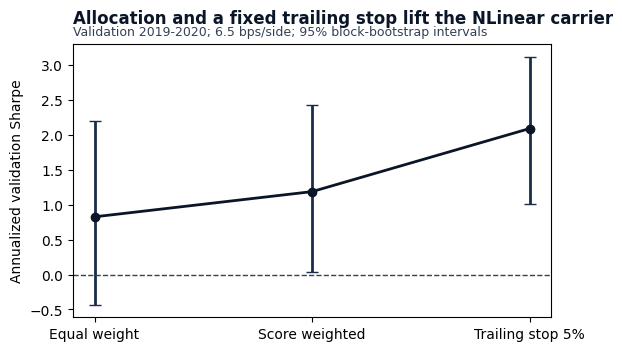

In [13]:
fig_stage, ax_stage = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
x = list(range(len(carrier)))
points = carrier["sharpe"].to_list()
lower = carrier["sharpe_ci95_lo"].to_list()
upper = carrier["sharpe_ci95_hi"].to_list()
ax_stage.errorbar(
    x,
    points,
    yerr=[
        [point - lo for point, lo in zip(points, lower, strict=True)],
        [hi - point for point, hi in zip(points, upper, strict=True)],
    ],
    marker="o",
    color=COLORS["blue"],
    ecolor=COLORS["slate"],
    capsize=4,
    linewidth=2,
)
ax_stage.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=1)
ax_stage.set_xticks(x, carrier["stage"].to_list())
ax_stage.set_ylabel("Annualized validation Sharpe")
add_message_title(
    ax_stage,
    "Allocation and a fixed trailing stop lift the NLinear carrier",
    f"Validation 2019-2020; {CONFIGURED_COST_BPS:.1f} bps/side; 95% block-bootstrap intervals",
)
fig_stage.show()

## 2. Cost survival on the same allocation lineage

The cost diagnostic belongs to the allocation carrier, before the risk rule.
Exact planned hashes keep alternate lineages and removed allocators out of the
curve.

In [14]:
cost_plans = []
for cost_bps in get_cost_grid_bps(CASE_STUDY):
    spec = set_backtest_costs_bps(
        clone_backtest_spec(base_spec),
        commission_bps=cost_bps / 2,
        slippage_bps=cost_bps / 2,
    )
    spec["chapter"] = "ch18"
    cost_plans.append(
        {
            "regime": "bps",
            "cost_value": float(cost_bps),
            "backtest_hash": backtest_hash_from_parts(strategy_carrier["prediction_hash"], spec),
        }
    )

The per-share companion uses the same carrier and changes only the cost
convention.

In [15]:
for half_spread in get_cost_grid_half_spread_usd(CASE_STUDY):
    spec = set_backtest_costs_per_share(
        clone_backtest_spec(base_spec),
        per_share=get_per_share_commission(CASE_STUDY),
        default_half_spread_usd=half_spread,
    )
    spec["chapter"] = "ch18"
    cost_plans.append(
        {
            "regime": "per_share",
            "cost_value": float(half_spread),
            "backtest_hash": backtest_hash_from_parts(strategy_carrier["prediction_hash"], spec),
        }
    )

In [16]:
cost_hashes = [plan["backtest_hash"] for plan in cost_plans]
with sqlite3.connect(REGISTRY_DB) as db:
    cost_metrics = pl.read_database(
        f"""
        SELECT b.backtest_hash, b.stage, bm.sharpe,
               bm.sharpe_ci95_lo, bm.sharpe_ci95_hi
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        WHERE b.backtest_hash IN ({",".join("?" for _ in cost_hashes)})
        """,
        connection=db,
        execute_options={"parameters": cost_hashes},
    )
cost_surface = pl.DataFrame(cost_plans).join(cost_metrics, on="backtest_hash", how="inner")
if len(cost_surface) != len(cost_plans):
    raise RuntimeError(f"Expected {len(cost_plans)} cost rows, found {len(cost_surface)}")
if cost_surface.filter(pl.col("stage") != "cost_sensitivity").height:
    raise RuntimeError("A corrected cost hash has the wrong registry stage")

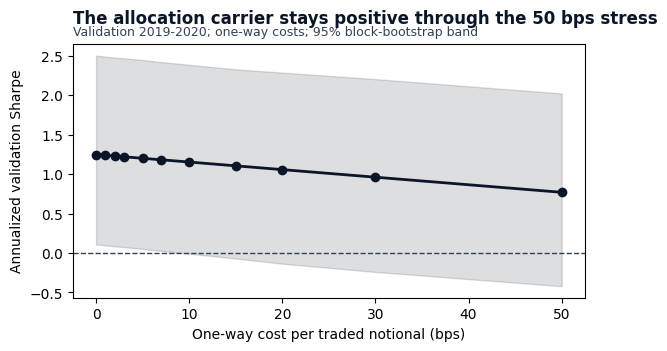

In [17]:
bps = cost_surface.filter(pl.col("regime") == "bps").sort("cost_value")
fig_cost, ax_cost = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
ax_cost.plot(
    bps["cost_value"],
    bps["sharpe"],
    marker="o",
    color=COLORS["blue"],
    linewidth=2,
)
ax_cost.fill_between(
    bps["cost_value"],
    bps["sharpe_ci95_lo"],
    bps["sharpe_ci95_hi"],
    color=COLORS["blue"],
    alpha=0.14,
)
ax_cost.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=1)
ax_cost.set_xlabel("One-way cost per traded notional (bps)")
ax_cost.set_ylabel("Annualized validation Sharpe")
add_message_title(
    ax_cost,
    "The allocation carrier stays positive through the 50 bps stress",
    "Validation 2019-2020; one-way costs; 95% block-bootstrap band",
)
fig_cost.show()

The point estimate decays gradually across the test grid, but its uncertainty
lower bound first crosses zero at 10 bps. Cost survival is therefore a robustness
result for the point path, not a precise estimate of net performance.

## 3. Paired risk effect and risk-cohort selection adjustment

The risk winner is compared with its exact allocation baseline on aligned
timestamps. The risk-only cohort then asks how much of the apparent winner
could arise from choosing among 14 controls. It does not erase the earlier
model and allocation search, so it is a lower bound on the total search cost.

In [18]:
baseline_returns = load_daily_returns_with_timestamp(CASE_STUDY, strategy_carrier["backtest_hash"])
winner_returns = load_daily_returns_with_timestamp(CASE_STUDY, risk_winner["backtest_hash"])
if baseline_returns is None or winner_returns is None:
    raise RuntimeError("Missing daily returns for the corrected carrier")
aligned = (
    baseline_returns.rename({"ret": "baseline_ret"})
    .join(winner_returns.rename({"ret": "winner_ret"}), on="timestamp", how="inner")
    .sort("timestamp")
)
nonzero = aligned.with_row_index().filter(
    (pl.col("baseline_ret").abs() > 1e-15) | (pl.col("winner_ret").abs() > 1e-15)
)
aligned = aligned.slice(nonzero["index"].min())
paired_risk = compute_paired_uncertainty(
    aligned["winner_ret"],
    aligned["baseline_ret"],
    periods_per_year=PERIODS_PER_YEAR,
    case_study=CASE_STUDY,
    label=LABEL,
    n_boot=2000,
    seed=SEED,
)

Selection adjustment uses only the 14 predeclared risk overlays and keeps
the no-overlay carrier as the economic benchmark.

In [19]:
returns_by_hash = {
    backtest_hash: load_daily_returns_with_timestamp(CASE_STUDY, backtest_hash)
    for backtest_hash in risk_surface["backtest_hash"]
}
fold_returns_by_hash = {
    backtest_hash: load_backtest_fold_metrics(CASE_STUDY, backtest_hash=backtest_hash)[
        "sharpe"
    ].to_numpy()
    for backtest_hash in risk_surface["backtest_hash"]
}
risk_cohort = compute_cohort_metrics(
    returns_by_hash,
    periods_per_year=PERIODS_PER_YEAR,
    baseline_returns=baseline_returns,
    fold_returns_by_hash=fold_returns_by_hash,
    rademacher_n_simulations=2000,
    rademacher_seed=SEED,
)
if (
    risk_winner["risk_type"] != "none"
    and risk_cohort.get("leader_hash") != risk_winner["backtest_hash"]
):
    raise RuntimeError("Risk cohort leader does not match the corrected carrier")

In [20]:
risk_diagnostics = pl.DataFrame(
    [
        {"diagnostic": "Paired Sharpe difference", "value": paired_risk["sharpe_diff"]},
        {"diagnostic": "Paired 95% lower bound", "value": paired_risk["sharpe_diff_ci95_lo"]},
        {"diagnostic": "Paired 95% upper bound", "value": paired_risk["sharpe_diff_ci95_hi"]},
        {"diagnostic": "Bootstrap win probability", "value": paired_risk["prob_challenger_wins"]},
        {"diagnostic": "Risk-cohort DSR ER p-value", "value": risk_cohort["dsr_er_pvalue"]},
        {"diagnostic": "Risk-cohort PBO", "value": risk_cohort["pbo"]},
        {"diagnostic": "Risk-cohort folds", "value": risk_cohort["pbo_n_folds"]},
    ]
)
risk_diagnostics

diagnostic,value
str,f64
"""Paired Sharpe difference""",0.90675
"""Paired 95% lower bound""",0.066915
"""Paired 95% upper bound""",1.684537
"""Bootstrap win probability""",0.9825
"""Risk-cohort DSR ER p-value""",0.003816
"""Risk-cohort PBO""",0.5
"""Risk-cohort folds""",2.0


The five-percent trailing stop's paired Sharpe improvement is 0.907 with a
95% interval of [0.067, 1.685]. The selection-adjusted diagnostics below
account for choosing among the 14 fixed controls, but only two validation
folds remain available for temporal stability analysis.

## 4. Holdout status: preserved observation, unresolved current carrier

The 2021 holdout has already been observed on an IPCA risk-adjusted-return
lineage. The corrected carrier uses a different family, label, allocation,
and risk rule. Running it now would turn the holdout into another selection
round. This notebook therefore checks that no matching NLinear holdout exists
and reports the stored IPCA row only as historical context.

In [21]:
with sqlite3.connect(REGISTRY_DB) as db:
    current_training_hash = db.execute(
        """
        SELECT p.training_hash
        FROM prediction_sets p
        WHERE p.prediction_hash = ?
        """,
        (strategy_carrier["prediction_hash"],),
    ).fetchone()[0]
    current_holdout_count = db.execute(
        """
        SELECT COUNT(*)
        FROM prediction_sets
        WHERE training_hash = ? AND split = 'holdout'
        """,
        (current_training_hash,),
    ).fetchone()[0]
    historical_rows = db.execute(
        """
        SELECT b.backtest_hash, t.family, t.config_name, t.label,
               b.spec_json, bm.sharpe, bm.sharpe_ci95_lo,
               bm.sharpe_ci95_hi, bm.max_drawdown
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        JOIN prediction_sets p ON b.prediction_hash = p.prediction_hash
        JOIN training_runs t ON p.training_hash = t.training_hash
        WHERE p.split = 'holdout'
        ORDER BY bm.sharpe DESC
        """
    ).fetchall()

In [22]:
if current_holdout_count != 0:
    raise RuntimeError("A holdout prediction unexpectedly exists for the corrected carrier")
if not historical_rows:
    raise RuntimeError("The preserved historical holdout row is missing")

historical_holdout = []
for row in historical_rows:
    spec = json.loads(row[4])
    strategy = strategy_view(spec)
    historical_holdout.append(
        {
            "backtest_hash": row[0],
            "family": row[1],
            "config": row[2],
            "label": row[3],
            "allocator": strategy.get("allocation", {}).get("method"),
            "risk": strategy.get("risk", {}).get("name"),
            "sharpe": row[5],
            "sharpe_ci_lo": row[6],
            "sharpe_ci_hi": row[7],
            "max_drawdown": row[8],
            "status": "historical, not comparable to corrected carrier",
        }
    )

print(f"Matching holdout predictions for corrected carrier: {current_holdout_count}")
pl.DataFrame(historical_holdout)

Matching holdout predictions for corrected carrier: 0


backtest_hash,family,config,label,allocator,risk,sharpe,sharpe_ci_lo,sharpe_ci_hi,max_drawdown,status
str,str,str,str,str,str,f64,f64,f64,f64,str
"""6e324a7e9f68""","""latent_factors""","""ipca""","""fwd_ret_risk_adj_5d""","""conformal_weighted""","""trailing_3pct""",0.420794,-1.287479,2.22511,-0.058746,"""historical, not comparable to …"


The stored IPCA/conformal holdout Sharpe is 0.421 with a 95% interval of
[-1.287, 2.225]. It neither validates nor refutes the corrected NLinear
carrier. The current carrier's out-of-sample status is unresolved and needs a
future untouched evaluation window.

## 5. Publication assessment

The corrected validation record is internally closed: all planned allocation,
cost, and risk hashes exist; the selected risk result reproduces exactly; and
its point-in-time and paired-uncertainty checks pass. The missing item is not a
computation failure. It is the deliberate absence of a second use of the
already-observed holdout.

In [23]:
assessment = pl.DataFrame(
    [
        {
            "gate": "Corrected validation carrier",
            "status": "PASS",
            "evidence": "NLinear / score weighted / top 10 / trailing stop 5%",
        },
        {
            "gate": "Validation Sharpe uncertainty",
            "status": "PASS",
            "evidence": "2.088 [1.005, 3.117]",
        },
        {
            "gate": "Paired risk improvement",
            "status": "PASS",
            "evidence": "+0.907 [0.067, 1.685]",
        },
        {
            "gate": "50 bps point stress",
            "status": "PASS",
            "evidence": "Sharpe 0.769; uncertainty includes zero",
        },
        {
            "gate": "Matching untouched holdout",
            "status": "UNRESOLVED",
            "evidence": "not run; 2021 holdout already observed on IPCA",
        },
        {
            "gate": "Deployment claim",
            "status": "FAIL",
            "evidence": "validation-positive is not out-of-sample efficacy",
        },
    ]
)
assessment

gate,status,evidence
str,str,str
"""Corrected validation carrier""","""PASS""","""NLinear / score weighted / top…"
"""Validation Sharpe uncertainty""","""PASS""","""2.088 [1.005, 3.117]"""
"""Paired risk improvement""","""PASS""","""+0.907 [0.067, 1.685]"""
"""50 bps point stress""","""PASS""","""Sharpe 0.769; uncertainty incl…"
"""Matching untouched holdout""","""UNRESOLVED""","""not run; 2021 holdout already …"
"""Deployment claim""","""FAIL""","""validation-positive is not out…"


## Key takeaways

1. The technically corrected v3.1 validation carrier is NLinear with score
   weighting, ten stocks, and a five-percent trailing stop.
2. Validation Sharpe progresses from 0.826 at equal weight to 1.186 after
   allocation and 2.088 after the risk rule; the final 95% interval is
   [1.005, 3.117].
3. The risk rule's paired improvement is +0.907 [0.067, 1.685]. Selection
   adjustment covers the 14 fixed controls, but only two validation folds
   remain for stability analysis.
4. The allocation carrier retains point Sharpe 0.769 at the 50 bps stress,
   although its uncertainty interval first crosses zero at 10 bps.
5. The existing IPCA/conformal holdout is historical and not comparable to
   the corrected carrier. A matching NLinear holdout was not run because the
   2021 window has already been observed.
6. Publication may present v3.1 as a corrected validation record, but it must
   label out-of-sample efficacy unresolved and make no deployment claim.